**Taller de Modelado Matemático I**

**Proyecto Integrador: Precios de cierre de Ford**

**Elaborado por: Ricardo Daniel Moreno Padilla**

**Matrícula: 2253801126**

**Justificación de la base de datos**

Para este proyecto se seleccionó una base de datos histórica de los precios de las acciones de Ford correspondiente al periodo comprendido entre septiembre de 2019 y septiembre de 2023. Esta base contiene información diaria de los precios de apertura, máximo, mínimo y cierre de la acción, lo que la convierte en una fuente adecuada para el estudio de series temporales financieras.

El fenómeno que se desea analizar es la evolución temporal del precio de cierre de las acciones de Ford y la posibilidad de predecir su comportamiento futuro a partir de información histórica. Específicamente, se busca determinar si los precios observados en días anteriores, junto con indicadores derivados como medias móviles y rendimientos, contienen información suficiente para estimar el precio de cierre del día siguiente o anticipar si éste aumentará o disminuirá.



Con todo lo anterior en mente, nos hacemos la siguiente pregunta:

**¿Podemos predecir el precio de cierre de las acciones de Ford del siguiente día?**

In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use('default')

Lo primero que haremos será cargar nuestra base de datos.

In [307]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Bases_datos_proyecto_integrador/precios_cierre_FORD.csv"
df = pd.read_csv(ruta)
df.head()

,Date,Open,High,Low,Close,Adj Close
0,2019-09-30,9.11,9.21,9.10,9.16,7.847744
1,2019-10-01,9.19,9.24,8.87,8.90,7.624991
2,2019-10-02,8.85,8.86,8.44,8.61,7.376537
3,2019-10-03,8.55,8.71,8.45,8.71,7.462211
4,2019-10-04,8.72,8.76,8.66,8.74,7.487914


In [308]:
print("Dimensiones:")
print(df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

Dimensiones:
(1006, 6)

Tipos de datos:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
dtype: object

Valores faltantes:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
dtype: int64


Ahora, transformemos la variable Fechas en una serie temporal

In [309]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

df.head()

,Date,Open,High,Low,Close,Adj Close
0,2019-09-30,9.11,9.21,9.10,9.16,7.847744
1,2019-10-01,9.19,9.24,8.87,8.90,7.624991
2,2019-10-02,8.85,8.86,8.44,8.61,7.376537
3,2019-10-03,8.55,8.71,8.45,8.71,7.462211
4,2019-10-04,8.72,8.76,8.66,8.74,7.487914


In [310]:
df.describe()

,Date,Open,High,Low,Close,Adj Close
count,1006,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000
mean,2021-09-27 03:36:08.588468992,11.969901,12.162704,11.767336,11.966064,10.865507
min,2019-09-30 00:00:00,4.270000,4.420000,3.960000,4.010000,3.551299
25%,2020-09-28 06:00:00,8.970000,9.050000,8.880000,8.982500,7.846066
50%,2021-09-27 12:00:00,12.220000,12.420000,12.050000,12.205000,11.441550
75%,2022-09-26 18:00:00,14.090000,14.290000,13.900000,14.087500,12.929274
max,2023-09-27 00:00:00,24.870001,25.870001,24.370001,25.190001,22.420860
std,NaN,3.918174,3.998388,3.840100,3.923812,3.602835


Veamos cuál es el periodo cubierto por la serie temporal de Ford.

In [311]:
print("Fecha inicial:", df["Date"].min())
print("Fecha final:", df["Date"].max())

Fecha inicial: 2019-09-30 00:00:00
Fecha final: 2023-09-27 00:00:00


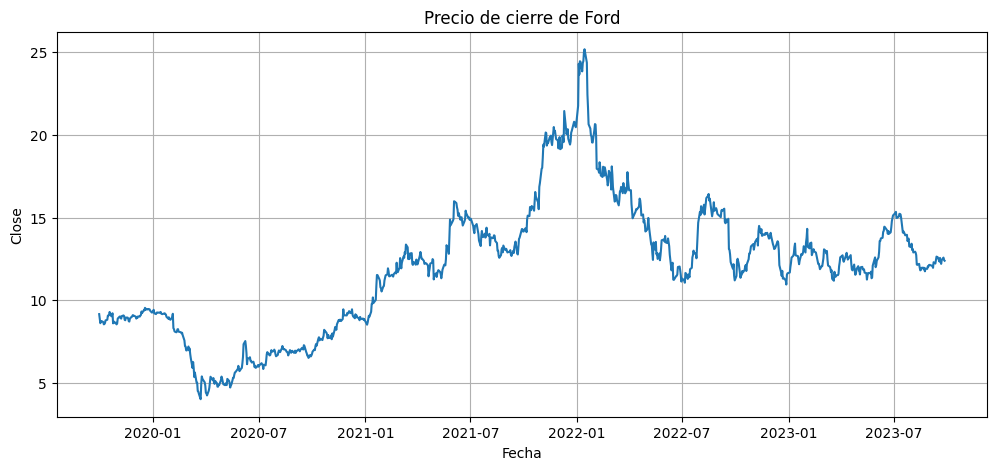

In [312]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Close"])

plt.title("Precio de cierre de Ford")
plt.xlabel("Fecha")
plt.ylabel("Close")

plt.grid(True)

plt.show()

La base de datos contiene 1006 observaciones diarias correspondientes al precio de las acciones de Ford entre septiembre de 2019 y septiembre de 2023. La variable principal de estudio es el precio de cierre (Close), ya que representa el valor final de negociación de cada jornada bursátil. A partir de la gráfica temporal se observan fluctuaciones importantes asociadas a la volatilidad propia del mercado financiero. Presentando el pico más alto, alrededor de enero y febrero del 2022. Y el pico más bajo, alrededor de abril o mayo del 2020.

Construiremos las variables predictoras que utilizarán los modelos.

La variable objetivo de regresión será $$C_{t+1}$$ esto es, el precio de cierre del día siguiente. Nuestras demás variables predictoras serán (en días)
$$C_{t}, \quad C_{t-1}, \quad C_{t-2}, \quad C_{t-3} $$

$$MA_{3}, \quad MA_{5}, MA_{10}$$

$$\Delta C_{t}=C_{t}-C_{t-1}, \quad t_{t}=\dfrac{\Delta_{t}}{C_{t-1}} $$

In [313]:
df_model = df.copy()

# Rezagos del precio de cierre

df_model["Close_t"] = df_model["Close"]

df_model["Close_t-1"] = df_model["Close"].shift(1)

df_model["Close_t-2"] = df_model["Close"].shift(2)

df_model["Close_t-3"] = df_model["Close"].shift(3)

df_model.head()

,Date,Open,High,Low,Close,Adj Close,Close_t,Close_t-1,Close_t-2,Close_t-3
0,2019-09-30,9.11,9.21,9.10,9.16,7.847744,9.16,NaN,NaN,NaN
1,2019-10-01,9.19,9.24,8.87,8.90,7.624991,8.90,9.16,NaN,NaN
2,2019-10-02,8.85,8.86,8.44,8.61,7.376537,8.61,8.90,9.16,NaN
3,2019-10-03,8.55,8.71,8.45,8.71,7.462211,8.71,8.61,8.90,9.16
4,2019-10-04,8.72,8.76,8.66,8.74,7.487914,8.74,8.71,8.61,8.90


Ahora, las médias móviles.

In [314]:
df_model["MA_3"] = df_model["Close"].rolling(window=3).mean()

df_model["MA_5"] = df_model["Close"].rolling(window=5).mean()

df_model["MA_10"] = df_model["Close"].rolling(window=10).mean()

Diferencia diaria

In [315]:
df_model["Delta_Close"] = df_model["Close"].diff()

Rendimiento porcentual

In [316]:
df_model["Return"] = df_model["Close"].pct_change()

La siguiente variable, es nuestra variable objetivo para la regresión.

In [317]:
df_model["Target_Regression"] = df_model["Close"].shift(-1)

Nuestra variable objetivo para la clasificación será:

$$Y_{t+1}=1 \text{ si } C_{t+1}>C_{t}$$
$$Y_{t+1}=0 \text{ si } C_{t+1} \leq C_{t}$$

In [318]:
df_model["Target_Classification"] = (
    df_model["Target_Regression"] > df_model["Close"]
).astype(int)

Ya que las medias móviles y los rezagos generan valores faltantes, hay que eliminarlos.

In [319]:
df_model = df_model.dropna()

df_model.reset_index(drop=True, inplace=True)

print(df_model.shape)

(996, 17)


Entonces, ahora veamos en una tabla todas nuestras variables creadas, ya sin valores faltantes o nulos.

In [320]:
df_model[
    [
        "Date",
        "Close",
        "Close_t-1",
        "Close_t-2",
        "Close_t-3",
        "MA_3",
        "MA_5",
        "MA_10",
        "Delta_Close",
        "Return",
        "Target_Regression",
        "Target_Classification"
    ]
].head()

,Date,Close,Close_t-1,Close_t-2,Close_t-3,MA_3,MA_5,MA_10,Delta_Close,Return,Target_Regression,Target_Classification
0,2019-10-11,8.78,8.62,8.56,8.54,8.653333,8.636,8.730,0.16,0.018561,8.82,1
1,2019-10-14,8.82,8.78,8.62,8.56,8.740000,8.664,8.696,0.04,0.004556,9.07,1
2,2019-10-15,9.07,8.82,8.78,8.62,8.890000,8.770,8.713,0.25,0.028345,9.07,0
3,2019-10-16,9.07,9.07,8.82,8.78,8.986667,8.872,8.759,0.00,0.000000,9.11,1
4,2019-10-17,9.11,9.07,9.07,8.82,9.083333,8.970,8.799,0.04,0.004410,9.29,1


Tenemos nuestra primer matriz de correlación.

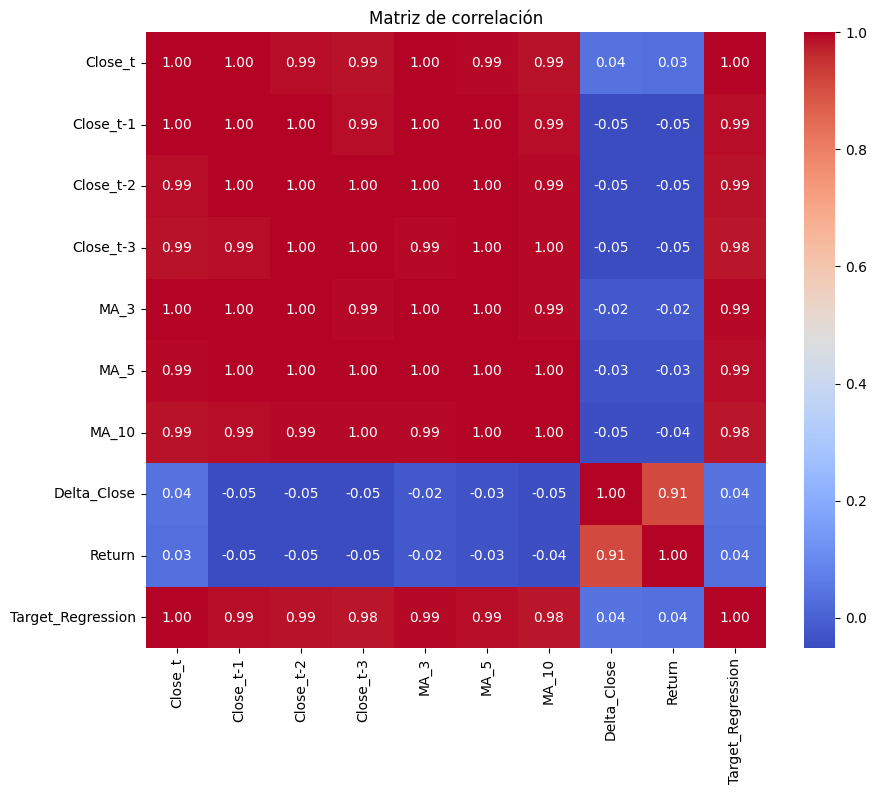

In [321]:
variables = [
    "Close_t",
    "Close_t-1",
    "Close_t-2",
    "Close_t-3",
    "MA_3",
    "MA_5",
    "MA_10",
    "Delta_Close",
    "Return",
    "Target_Regression"
]

corr = df_model[variables].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

Observemos que la correlación de las variables bredictoras con $C_{t+1}$ es la siguiente:


*   close_t ----Muy alta
*   close_t-1---Muy alta
*   close_t-2---Muy alta
*   close_t-3---Muy alta
*   MA_3--------Muy alta
*   MA_5--------Muy alta
*   MA_10-------Muy alta
*   Delta_close---baja



Veamos cuál es la evolución de las medias móviles.

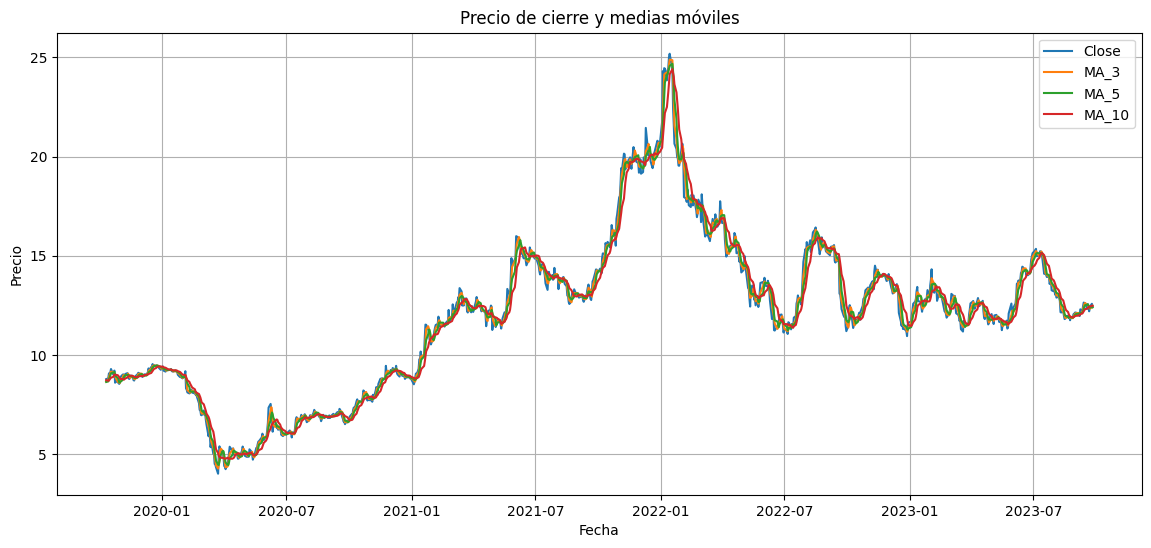

In [322]:
plt.figure(figsize=(14,6))

plt.plot(
    df_model["Date"],
    df_model["Close"],
    label="Close"
)

plt.plot(
    df_model["Date"],
    df_model["MA_3"],
    label="MA_3"
)

plt.plot(
    df_model["Date"],
    df_model["MA_5"],
    label="MA_5"
)

plt.plot(
    df_model["Date"],
    df_model["MA_10"],
    label="MA_10"
)

plt.title("Precio de cierre y medias móviles")

plt.xlabel("Fecha")
plt.ylabel("Precio")

plt.legend()

plt.grid(True)

plt.show()

Con el propósito de capturar la dependencia temporal de la serie, se construyeron variables rezagadas del precio de cierre correspondientes a los tres días anteriores. Asimismo, se incorporaron medias móviles de 3, 5 y 10 días para representar tendencias de corto plazo. También se incluyeron la diferencia diaria y el rendimiento porcentual con el objetivo de capturar cambios recientes en el comportamiento del precio. Finalmente, se definieron dos variables objetivo: una para regresión, correspondiente al precio de cierre del día siguiente, y otra para clasificación, que indica si el precio aumenta o disminuye respecto al día actual.

Nuestro objetivo ahora el la predicción de $C_{t+1}$

In [323]:
features = [
    "Close_t",
    "Close_t-1",
    "Close_t-2",
    "Close_t-3",
    "MA_3",
    "MA_5",
    "MA_10",
    "Delta_Close",
    "Return"
]

X = df_model[features]

y = df_model["Target_Regression"]

Hagamos la división de nuestros datos, en datos de entrenamiento y datos de prueba. Será el 70% para los datos de entrenamiento y el 30% para los datos de prueba.

In [324]:
train_size = int(len(df_model)*0.70)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print("Observaciones entrenamiento:", len(X_train))
print("Observaciones prueba:", len(X_test))

Observaciones entrenamiento: 697
Observaciones prueba: 299


Comenzaremos con el modelo ingenuo, en el que se supone que mañana tendrá el mismo valor que hoy, esto es
$$C_{t+1}=C_{t}$$

In [325]:
y_pred_naive = X_test["Close_t"]

In [326]:
mae_naive = mean_absolute_error(
    y_test,
    y_pred_naive
)

rmse_naive = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_naive
    )
)

print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

MAE: 0.23545149832775925
RMSE: 0.3237251763962491


El modelo ingenuo constituye una línea base para evaluar el desempeño de los modelos más complejos. En este caso se supone que el precio de cierre del día siguiente será igual al precio observado en el día actual. Como se puede observar se obtuvo un MAE=0.2354 y un RMSE=0.3237, esto sugiere que el modelo ingenuo está haciendo buenas aproximaciones.

Ahora consideremos la regresión lineal

In [327]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

LinearRegression()

In [328]:
y_pred_lr = lr.predict(X_test)

In [329]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

MAE: 0.23425505133661298
RMSE: 0.32237260394514633


Después de aplicar la regresión lineal, podemos observar que en base a los valores obtenidos para el MAE y el RMSE, este modelo hace predicciones ligeramente mejores que las del modelo ingenuo.

In [330]:
coeficientes = pd.DataFrame(
    {
        "Variable": features,
        "Coeficiente": lr.coef_
    }
)

coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

,Variable,Coeficiente
0,Close_t,0.580413
7,Delta_Close,0.371832
4,MA_3,0.239850
1,Close_t-1,0.208581
5,MA_5,0.109326
6,MA_10,-0.030433
3,Close_t-3,-0.041982
2,Close_t-2,-0.069446
8,Return,-0.276495


La regresión lineal permite identificar la contribución de cada variable predictora sobre el precio futuro. Los coeficientes estimados muestran la influencia relativa de los rezagos, medias móviles y rendimientos sobre la variable objetivo. Se observa que la variable con mayor influencia sobre el valor futuro es close_t, es decir, el precio de cierre del día en curso. Otras variables como Delta_close, MA_3 y close_t-1 también son importantes, pero en menor medida a close_t.

El siguiente modelo a considerar es árboles de desición.

In [331]:
tree_reg = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_reg.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [332]:
y_pred_tree = tree_reg.predict(X_test)

In [333]:
mae_tree = mean_absolute_error(
    y_test,
    y_pred_tree
)

rmse_tree = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tree
    )
)

print("MAE:", mae_tree)
print("RMSE:", rmse_tree)

MAE: 0.2746490420903461
RMSE: 0.3608585030242723


El árbol de decisión modela relaciones no lineales entre las variables predictoras y el precio futuro. Este enfoque permite capturar patrones que una regresión lineal podría no representar adecuadamente.

De acuerdo a los valores obtenidos para el MAE y el RMSE, se observa que son mayores en comparación con los otros dos modelos. Entonces, intuitivamente podemos decir que, sus predicciones son ligeramente peores que las del modelo ingenuo o las de la regresión lineal.

Y seguiremos ahora con Random Forest.

In [334]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_estimators=200, random_state=42)

In [335]:
y_pred_rf = rf_reg.predict(X_test)

In [336]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

MAE: 0.2619123750501671
RMSE: 0.3416914855063853


Random Forest combina múltiples árboles de decisión para reducir la varianza de las predicciones y mejorar la capacidad predictiva del modelo.

Se observa que el valor de MAE y de RMSE mejoran con respecto al árbol de desición, sin embargo, no mejoran respecto al modelo ingenuo y la regresión lineal.

In [368]:
resultados_regresion = pd.DataFrame(
    {
        "Modelo":[
            "Ingenuo",
            "Regresión Lineal",
            "Árbol",
            "Random Forest"
        ],
        "MAE":[
            mae_naive,
            mae_lr,
            mae_tree,
            mae_rf
        ],
        "RMSE":[
            rmse_naive,
            rmse_lr,
            rmse_tree,
            rmse_rf
        ]
    }
)

resultados_regresion

,Modelo,MAE,RMSE
0,Ingenuo,0.235451,0.323725
1,Regresión Lineal,0.234255,0.322373
2,Árbol,0.274649,0.360859
3,Random Forest,0.261912,0.341691


In [338]:
resultados_regresion.sort_values(
    by="RMSE"
)

,Modelo,MAE,RMSE
1,Regresión Lineal,0.234255,0.322373
0,Ingenuo,0.235451,0.323725
3,Random Forest,0.261912,0.341691
2,Árbol,0.274649,0.360859


El mejor modelo será aquel que presente los menores valores de MAE y RMSE. Estas métricas permiten cuantificar la magnitud promedio de los errores de predicción.

Entonces, en base a lo mostrado en la tabla y en los análisis anteriores, el mejor modelo para hacer las predicciones resulta ser la regresión lineal, mostrando que no necesariamente el modelo más complejo es el mejor.

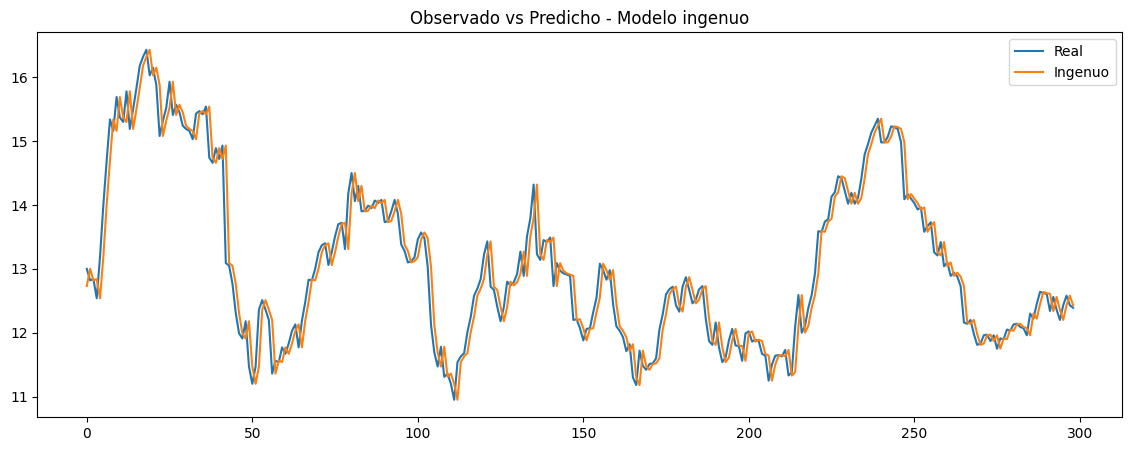

In [339]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values,
    label="Real"
)

plt.plot(
    y_pred_naive.values,
    label="Ingenuo"
)

plt.title(
    "Observado vs Predicho - Modelo ingenuo"
)

plt.legend()

plt.show()

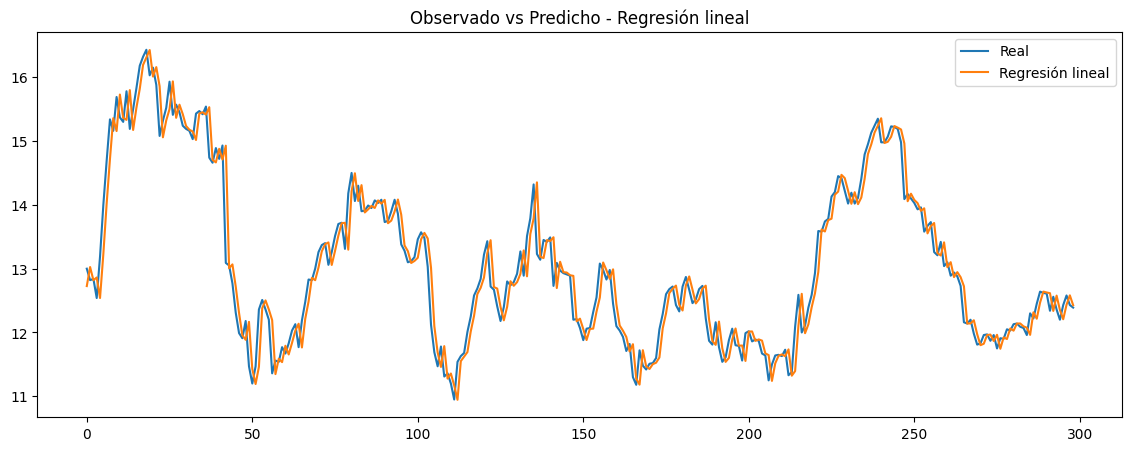

In [340]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values,
    label="Real"
)

plt.plot(
    y_pred_lr,
    label="Regresión lineal"
)

plt.title(
    "Observado vs Predicho - Regresión lineal"
)

plt.legend()

plt.show()

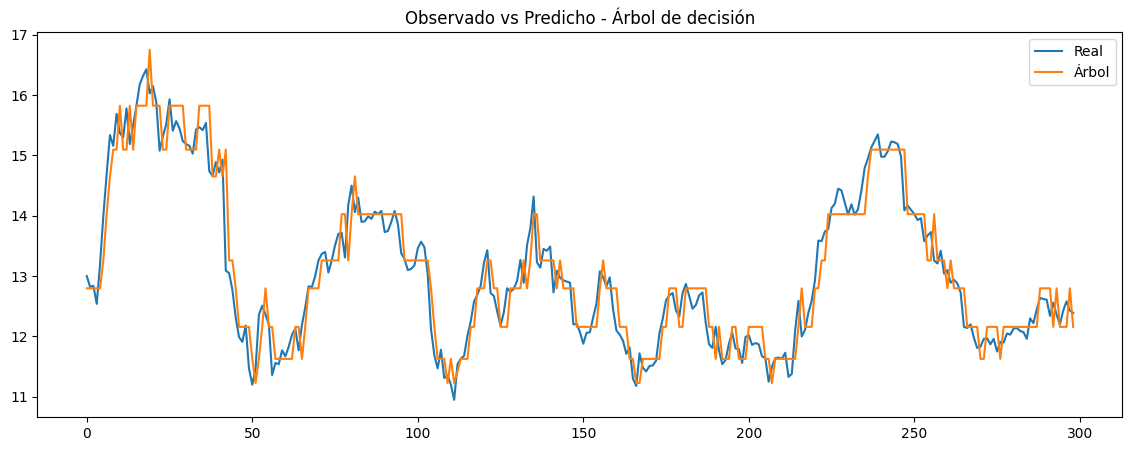

In [341]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values,
    label="Real"
)

plt.plot(
    y_pred_tree,
    label="Árbol"
)

plt.title(
    "Observado vs Predicho - Árbol de decisión"
)

plt.legend()

plt.show()

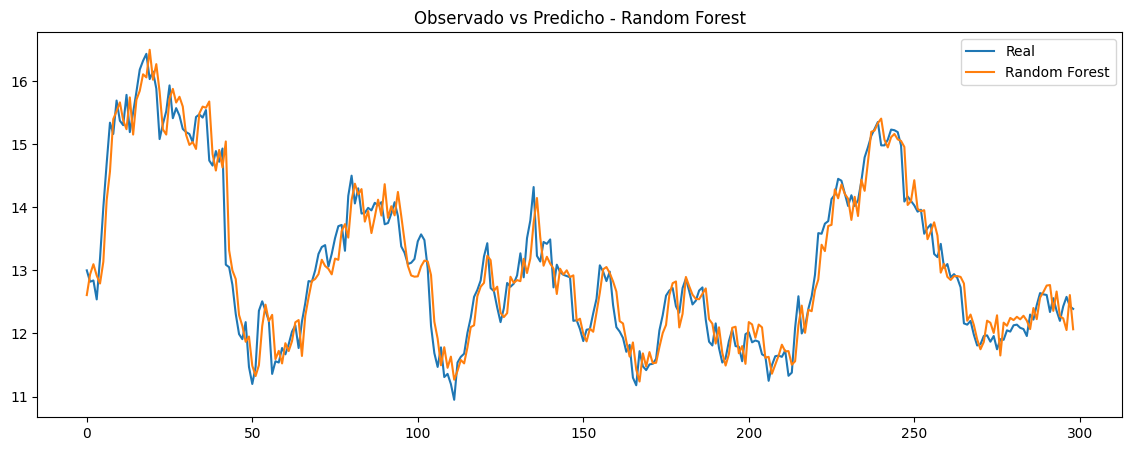

In [342]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values,
    label="Real"
)

plt.plot(
    y_pred_rf,
    label="Random Forest"
)

plt.title(
    "Observado vs Predicho - Random Forest"
)

plt.legend()

plt.show()

Los resultados obtenidos muestran el desempeño de distintos enfoques para predecir el precio de cierre de Ford del día siguiente. El modelo ingenuo sirve como referencia mínima de desempeño, mientras que la regresión lineal, el árbol de decisión y Random Forest permiten capturar relaciones más complejas entre las variables explicativas y la variable objetivo. La comparación mediante MAE y RMSE permite identificar cuál modelo proporciona las predicciones más precisas para esta serie financiera.

Ahora, en lugar de tratar de hacer la predicción exacta, trataremos de convertir nuestro problema en uno de clasificación, es decir, predecir si el precio subirá o bajará. Definimos

$$Y_{t+1} = 1 \text{ si } C_{t+1} > C_{t}$$
$$Y_{t+1} = 0 \text{ si } C_{t+1} \leq C_{t}$$

In [343]:
X_class = df_model[features]

y_class = df_model["Target_Classification"]

In [344]:
train_size = int(len(df_model)*0.70)

X_train_c = X_class.iloc[:train_size]
X_test_c  = X_class.iloc[train_size:]

y_train_c = y_class.iloc[:train_size]
y_test_c  = y_class.iloc[train_size:]

Distribución en clases

In [345]:
y_class.value_counts()

,count
Target_Classification,
0,513
1,483


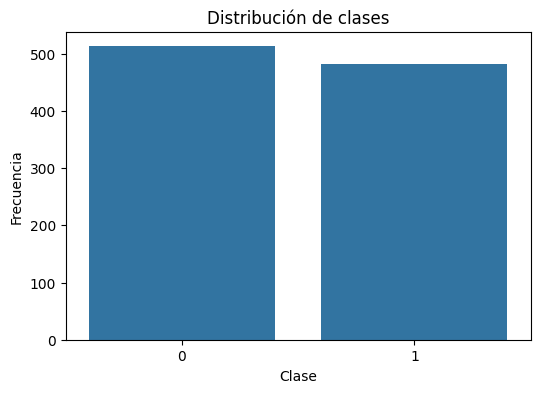

In [346]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_class)

plt.title("Distribución de clases")

plt.xlabel("Clase")

plt.ylabel("Frecuencia")

plt.show()

Antes de entrenar los modelos se analiza la distribución de las clases. Esto permite verificar si existe un desbalance significativo entre los días en los que el precio aumenta y aquellos en los que disminuye.

Tenemos primero el clasificador ingenuo

Al igual que en la parte de regresión, construiremos un modelo base.

La regla será:

$${Y}^{t+1} =1$$

si el rendimiento actual es positivo y

$$Y^{t+1}=0$$

en caso contrario.

In [347]:
y_pred_naive_class = (
    X_test_c["Delta_Close"] > 0
).astype(int)

In [348]:
acc_naive = accuracy_score(
    y_test_c,
    y_pred_naive_class
)

prec_naive = precision_score(
    y_test_c,
    y_pred_naive_class
)

rec_naive = recall_score(
    y_test_c,
    y_pred_naive_class
)

f1_naive = f1_score(
    y_test_c,
    y_pred_naive_class
)

print("Accuracy :", acc_naive)
print("Precision:", prec_naive)
print("Recall   :", rec_naive)
print("F1-score :", f1_naive)

Accuracy : 0.5150501672240803
Precision: 0.5408805031446541
Recall   : 0.5443037974683544
F1-score : 0.5425867507886435


Ahora consideraremos el árbol de desición:

In [349]:
tree_clf = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_clf.fit(
    X_train_c,
    y_train_c
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [350]:
y_pred_tree_class = tree_clf.predict(
    X_test_c
)

In [351]:
acc_tree = accuracy_score(
    y_test_c,
    y_pred_tree_class
)

prec_tree = precision_score(
    y_test_c,
    y_pred_tree_class
)

rec_tree = recall_score(
    y_test_c,
    y_pred_tree_class
)

f1_tree = f1_score(
    y_test_c,
    y_pred_tree_class
)

print("Accuracy :", acc_tree)
print("Precision:", prec_tree)
print("Recall   :", rec_tree)
print("F1-score :", f1_tree)

Accuracy : 0.47157190635451507
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


El árbol de decisión genera reglas de clasificación a partir de los rezagos y medias móviles, permitiendo capturar relaciones no lineales entre las variables predictoras y la dirección futura del precio.

Observación sobre el árbol de decisión. En el modelo de árbol de decisión se obtuvo un valor de Accuracy de aproximadamente 47%, mientras que las métricas de Precision, Recall y F1-score fueron iguales a cero. Este comportamiento se debe a que el clasificador predijo únicamente una de las dos clases (en este caso, la clase correspondiente a que el precio no aumenta), por lo que nunca identificó correctamente observaciones de la clase opuesta. Como consecuencia, no fue posible calcular la precisión para la clase positiva, y la biblioteca scikit-learn emitió una advertencia indicando que dicha métrica es indefinida en estas condiciones. Este resultado sugiere que, con la configuración utilizada, el árbol de decisión no logró encontrar reglas de partición que discriminaran adecuadamente entre ambas clases. Este tipo de comportamiento puede presentarse cuando la información disponible no permite separar claramente las clases o cuando la complejidad del modelo resulta insuficiente para capturar los patrones presentes en los datos.

Ahora, hagamos el caso del Random Forest

In [352]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_clf.fit(
    X_train_c,
    y_train_c
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [353]:
y_pred_rf_class = rf_clf.predict(
    X_test_c
)

In [354]:
acc_rf = accuracy_score(
    y_test_c,
    y_pred_rf_class
)

prec_rf = precision_score(
    y_test_c,
    y_pred_rf_class
)

rec_rf = recall_score(
    y_test_c,
    y_pred_rf_class
)

f1_rf = f1_score(
    y_test_c,
    y_pred_rf_class
)

print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1-score :", f1_rf)

Accuracy : 0.4816053511705686
Precision: 0.5118110236220472
Recall   : 0.41139240506329117
F1-score : 0.45614035087719296


Random Forest combina múltiples árboles de decisión y suele proporcionar una mejor capacidad de generalización al reducir la varianza presente en un único árbol.

Ahora, en la siguiente tabla, compararemos todos los clasificadores.

In [355]:
resultados_clasificacion = pd.DataFrame(
    {
        "Modelo":[
            "Ingenuo",
            "Árbol",
            "Random Forest"
        ],

        "Accuracy":[
            acc_naive,
            acc_tree,
            acc_rf
        ],

        "Precision":[
            prec_naive,
            prec_tree,
            prec_rf
        ],

        "Recall":[
            rec_naive,
            rec_tree,
            rec_rf
        ],

        "F1":[
            f1_naive,
            f1_tree,
            f1_rf
        ]
    }
)

resultados_clasificacion

,Modelo,Accuracy,Precision,Recall,F1
0,Ingenuo,0.515050,0.540881,0.544304,0.542587
1,Árbol,0.471572,0.000000,0.000000,0.000000
2,Random Forest,0.481605,0.511811,0.411392,0.456140


De la tabla, podemos observar que el mejor modelo clasificador fue el modelo ingenuo pues el accuracy que obtuvo fue mayor en comparación con los otros dos modelos.

In [356]:
resultados_clasificacion.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1
0,Ingenuo,0.515050,0.540881,0.544304,0.542587
2,Random Forest,0.481605,0.511811,0.411392,0.456140
1,Árbol,0.471572,0.000000,0.000000,0.000000


La comparación entre Accuracy, Precision, Recall y F1-score permite evaluar el desempeño global de cada clasificador. El F1-score resulta particularmente útil cuando se desea equilibrar precisión y sensibilidad.

Exploremos ahora la matriz de confusión de cada uno de los modelos.

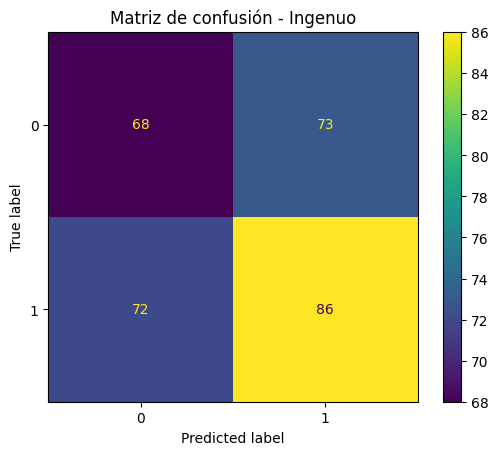

In [357]:
cm_naive = confusion_matrix(
    y_test_c,
    y_pred_naive_class
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_naive
)

disp.plot()

plt.title(
    "Matriz de confusión - Ingenuo"
)

plt.show()

El modelo ingenuo


*   En 68 días acertó que el precio no subiría.
*   En 86 días acertó que el precio subiría.
*   En 73 días predijo un aumento que no ocurrió.
*   En 72 días predijo una bajada que no ocurrió.



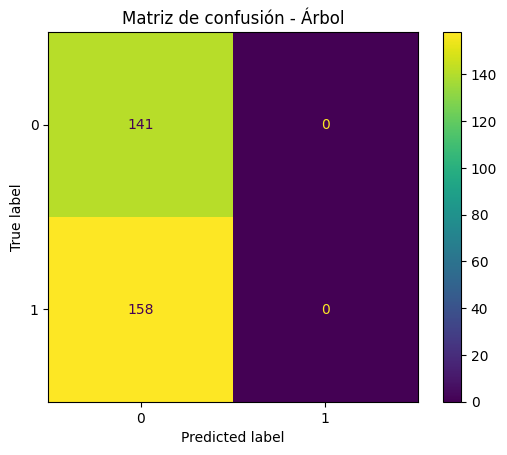

In [358]:
cm_tree = confusion_matrix(
    y_test_c,
    y_pred_tree_class
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree
)

disp.plot()

plt.title(
    "Matriz de confusión - Árbol"
)

plt.show()

La árbol de desición:

* En 141 días acertó que el precio no subiría.
* En 0 días acertó que el precio subiría.
* En 0 días predijo un aumento que no ocurrió.
* En 158 días predijo una bajada que no ocurrió.

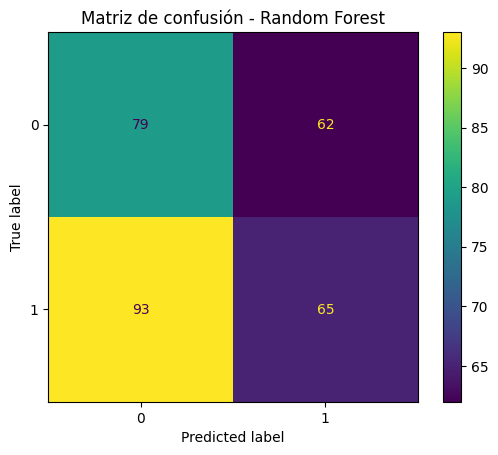

In [359]:
cm_rf = confusion_matrix(
    y_test_c,
    y_pred_rf_class
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title(
    "Matriz de confusión - Random Forest"
)

plt.show()

El Random Forest:

* En 79 días acertó que el precio no subiría.
* En 65 días acertó que el precio subiría.
* En 62 días predijo un aumento que no ocurrió.
* En 93 días predijo una bajada que no ocurrió.

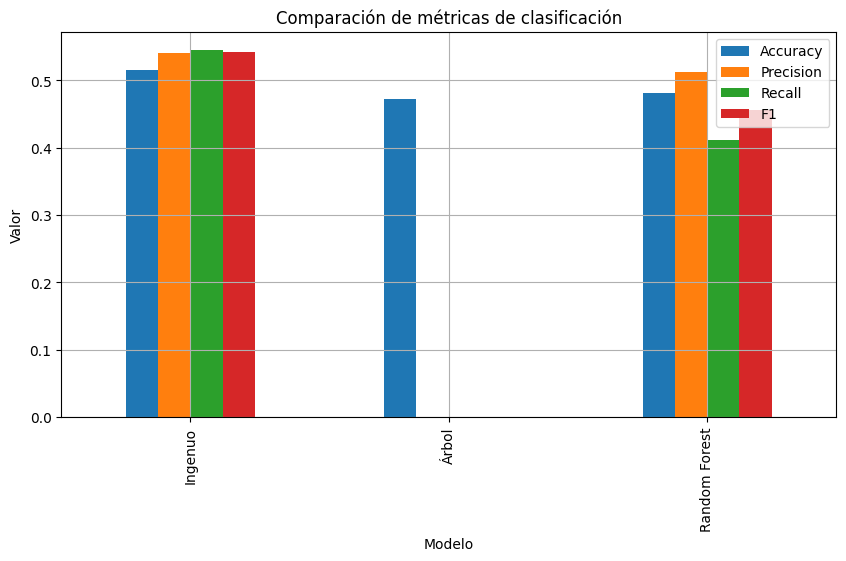

In [360]:
metricas = resultados_clasificacion.set_index(
    "Modelo"
)

metricas.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Comparación de métricas de clasificación"
)

plt.ylabel("Valor")

plt.grid(True)

plt.show()

Los modelos de clasificación permiten anticipar la dirección futura del precio de la acción, es decir, si el precio aumentará o disminuirá al día siguiente. Los resultados muestran el desempeño relativo de cada método mediante Accuracy, Precision, Recall y F1-score. La matriz de confusión proporciona una visión detallada de los aciertos y errores de clasificación para cada modelo.

In [361]:
importancias_reg = pd.DataFrame(
    {
        "Variable": features,
        "Importancia": rf_reg.feature_importances_
    }
)

importancias_reg = importancias_reg.sort_values(
    by="Importancia",
    ascending=False
)

importancias_reg

,Variable,Importancia
0,Close_t,0.793772
4,MA_3,0.091097
6,MA_10,0.058199
1,Close_t-1,0.022702
2,Close_t-2,0.014607
5,MA_5,0.013166
3,Close_t-3,0.005384
8,Return,0.000541
7,Delta_Close,0.000532


La variable más importante con creces es la del precio de cierre del día en curso.

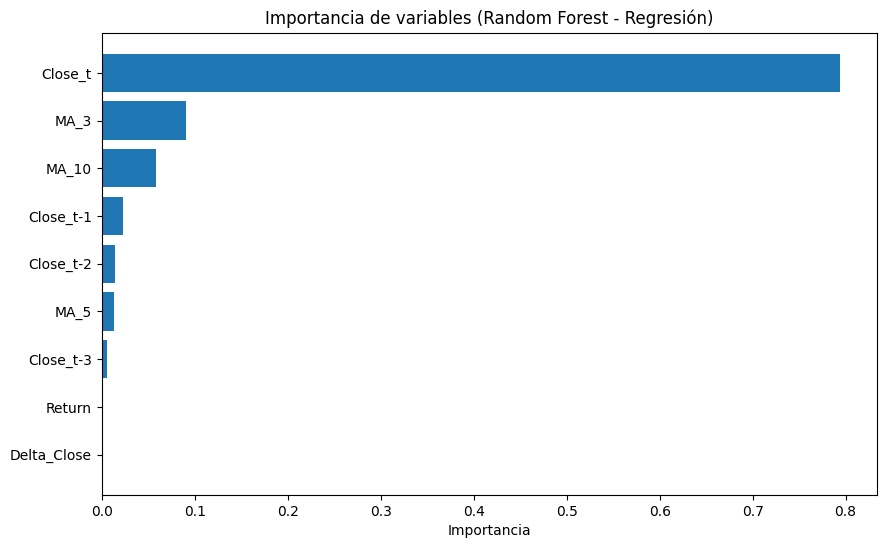

In [362]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias_reg["Variable"],
    importancias_reg["Importancia"]
)

plt.title(
    "Importancia de variables (Random Forest - Regresión)"
)

plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()

La gráfica de importancia muestra cuáles variables contribuyen en mayor medida a la predicción del precio de cierre futuro. Es esperable que el precio actual y los rezagos recientes tengan una importancia elevada, dado que los precios bursátiles presentan una fuerte dependencia temporal.

In [363]:
importancias_clf = pd.DataFrame(
    {
        "Variable": features,
        "Importancia": rf_clf.feature_importances_
    }
)

importancias_clf = importancias_clf.sort_values(
    by="Importancia",
    ascending=False
)

importancias_clf

,Variable,Importancia
6,MA_10,0.125593
3,Close_t-3,0.125406
8,Return,0.115553
5,MA_5,0.113436
1,Close_t-1,0.113331
0,Close_t,0.107166
2,Close_t-2,0.104377
4,MA_3,0.100399
7,Delta_Close,0.094739


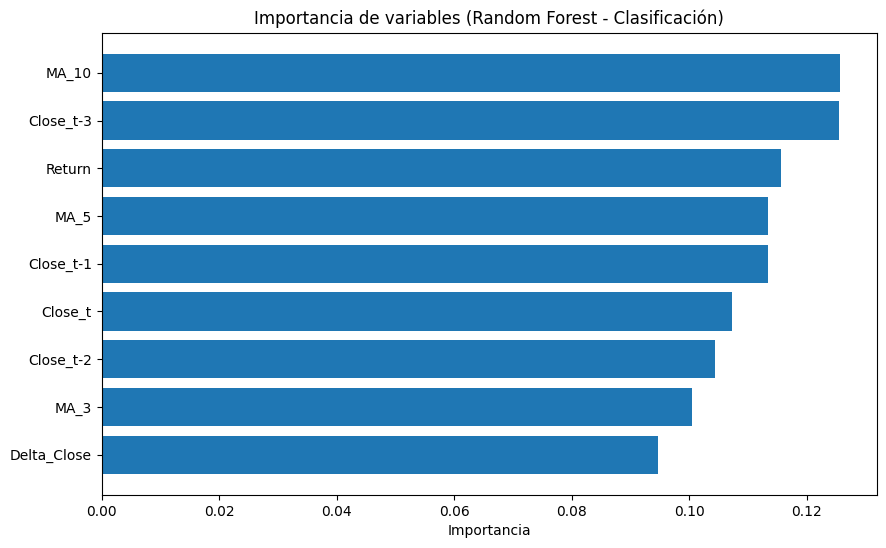

In [364]:
plt.figure(figsize=(10,6))

plt.barh(
    importancias_clf["Variable"],
    importancias_clf["Importancia"]
)

plt.title(
    "Importancia de variables (Random Forest - Clasificación)"
)

plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()

En el problema de clasificación, las variables más importantes son aquellas que contienen información relevante para anticipar la dirección futura del precio. Las medias móviles y los cambios recientes suelen ser especialmente útiles para este propósito. En este caso hay dos variables que destacan, MA_10 y close_t-3 pues estas variables contienen información histórica más significativa.

In [365]:
resultados_regresion.sort_values(
    by="RMSE"
)

,Modelo,MAE,RMSE
1,Regresión Lineal,0.234255,0.322373
0,Ingenuo,0.235451,0.323725
3,Random Forest,0.261912,0.341691
2,Árbol,0.274649,0.360859


La comparación de modelos de regresión muestra que los algoritmos basados en árboles pueden capturar relaciones no lineales presentes en la serie temporal. El mejor modelo será aquel que presente simultáneamente los menores valores de MAE y RMSE, siendo la regresión lineal el mejor modelo.

In [366]:
resultados_clasificacion.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1
0,Ingenuo,0.515050,0.540881,0.544304,0.542587
2,Random Forest,0.481605,0.511811,0.411392,0.456140
1,Árbol,0.471572,0.000000,0.000000,0.000000


Los modelos de clasificación permiten evaluar la capacidad de anticipar movimientos alcistas o bajistas del precio de la acción. El F1-score constituye una métrica adecuada para comparar el equilibrio entre precisión y sensibilidad.

Los resultados obtenidos muestran que el precio de cierre de Ford presenta una dependencia temporal significativa, lo cual justifica el uso de variables rezagadas y medias móviles como predictores.

En el problema de regresión, el modelo ingenuo proporciona una referencia inicial basada en la persistencia temporal del precio. Los modelos de aprendizaje automático permiten capturar relaciones más complejas y, dependiendo de los resultados obtenidos, pueden mejorar la precisión de las predicciones.

En el problema de clasificación, la tarea resulta más desafiante debido a la volatilidad inherente de los mercados financieros. Aunque algunos patrones temporales pueden ser detectados, los movimientos diarios del mercado contienen una componente aleatoria importante que limita la capacidad predictiva de cualquier modelo.

El análisis de importancia de variables muestra que los precios recientes y las medias móviles contienen la mayor parte de la información útil para la predicción, lo cual es consistente con la teoría de series temporales financieras.

**Conclusiones**

En este trabajo se desarrollaron modelos de regresión y clasificación para analizar el comportamiento del precio de cierre de las acciones de Ford utilizando información histórica correspondiente al periodo comprendido entre septiembre de 2019 y septiembre de 2023.

Se construyeron variables basadas en rezagos temporales, medias móviles y rendimientos con el objetivo de capturar la dinámica de la serie financiera.

Para el problema de regresión se compararon un modelo ingenuo, una regresión lineal, un árbol de decisión y un modelo Random Forest mediante las métricas MAE y RMSE. Para el problema de clasificación se compararon un clasificador ingenuo, un árbol de decisión y un modelo Random Forest utilizando Accuracy, Precision, Recall y F1-score.

Los resultados obtenidos permitieron identificar cuáles variables poseen mayor relevancia predictiva y determinar cuál de los modelos estudiados presenta el mejor desempeño para esta base de datos.

Finalmente, el análisis confirma que los modelos basados en aprendizaje automático constituyen herramientas útiles para el estudio de series financieras, aunque la incertidumbre inherente de los mercados limita la capacidad de realizar predicciones completamente precisas.
